In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

csv_path = Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/FC_pruning_raw_results.csv')
output_dir = Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/pruning_figures')
output_dir.mkdir(parents=True, exist_ok=True)

selected_ratio = 50
error_type = 'std'  # 可设置为'std'或'sem'
pruning_ratios = np.array([20, 30, 40, 50])
preferred_methods = ['fc_ls', 'flap', 'sobp', 'fand', 'slimllm', 'wanda']

colors = {
    'fc_ls': '#86383f',
    'flap': '#42949E',
    'sobp': '#4F7CAC',
    'fand': '#9A4D8E',
    'slimllm': '#D28E2D',
    'wanda': '#6F6F6F'
}

markers = {method: 'o' for method in preferred_methods}

df = pd.read_csv(csv_path)
required_columns = {'model', 'domain', 'seed', 'method', 'ratio', 'ppl'}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'CSV缺少以下列: {sorted(missing_columns)}')

df['ratio'] = df['ratio'].astype(str).str.replace('%', '', regex=False).astype(float)
if df['ratio'].max() <= 1:
    df['ratio'] = df['ratio'] * 100

df['ppl'] = pd.to_numeric(df['ppl'], errors='raise')
df['method'] = df['method'].astype(str)

present_methods = df['method'].drop_duplicates().tolist()
methods = [method for method in preferred_methods if method in present_methods]
methods += [method for method in present_methods if method not in methods]

domains = df['domain'].drop_duplicates().tolist()
models = df['model'].drop_duplicates().tolist()
panel_order = [(domain, model) for domain in domains for model in models if ((df['domain'] == domain) & (df['model'] == model)).any()]

if len(panel_order) != 4:
    raise ValueError(f'检测到{len(panel_order)}个model-domain组合，而不是预期的4个组合: {panel_order}')

seed_counts = df.groupby(['model', 'domain', 'method', 'ratio'])['seed'].nunique()
if (seed_counts != 10).any():
    print('以下条件的随机种子数不等于10:')
    print(seed_counts[seed_counts != 10])

summary_df = df.groupby(['model', 'domain', 'method', 'ratio'], as_index=False)['ppl'].agg(['mean', 'std', 'count']).reset_index()
summary_df['sem'] = summary_df['std'] / np.sqrt(summary_df['count'])

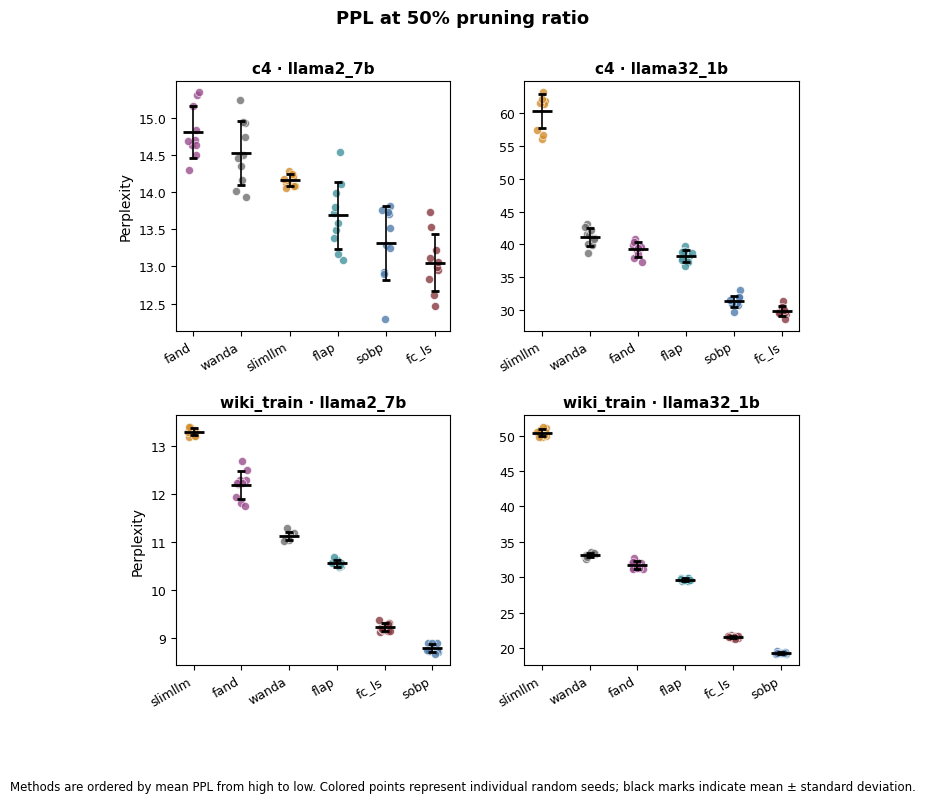

In [16]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 2, figsize=(7, 8))
axes = axes.flatten()

for panel_idx, (domain, model) in enumerate(panel_order):
    ax = axes[panel_idx]
    panel_df = df[(df['domain'] == domain) & (df['model'] == model) & np.isclose(df['ratio'], selected_ratio)].copy()

    method_means = panel_df.groupby('method')['ppl'].mean()
    panel_methods = method_means.sort_values(ascending=False).index.tolist()

    for method_idx, method in enumerate(panel_methods):
        values = panel_df.loc[panel_df['method'] == method, 'ppl'].to_numpy(dtype=float)
        if len(values) == 0:
            continue

        x = method_idx + rng.uniform(-0.12, 0.12, len(values))
        mean = values.mean()
        std = values.std(ddof=1)
        color = colors.get(method, '#6F6F6F')

        ax.scatter(x, values, s=34, color=color, alpha=0.8, edgecolor='white', linewidth=0.5, zorder=3)
        ax.errorbar(method_idx, mean, yerr=std, fmt='_', color='black', markersize=14, markeredgewidth=2.0, elinewidth=1.2, capsize=3, capthick=1.2, zorder=5)

    ax.set_title(f'{domain} · {model}', fontsize=11, fontweight='bold')
    ax.set_xticks(np.arange(len(panel_methods)))
    ax.set_xticklabels(panel_methods, rotation=30, ha='right')
    ax.tick_params(axis='both', labelsize=9, direction='out', length=3.5, width=0.8)
    # ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)

    if panel_idx % 2 == 0:
        ax.set_ylabel('Perplexity', fontsize=10)

fig.suptitle(f'PPL at {selected_ratio}% pruning ratio', fontsize=13, fontweight='bold', y=0.99)
fig.text(0.5, 0.01, 'Methods are ordered by mean PPL from high to low. Colored points represent individual random seeds; black marks indicate mean ± standard deviation.', ha='center', va='bottom', fontsize=8.5)
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.17, top=0.90, wspace=0.27, hspace=0.34)

plt.savefig(output_dir / f'ppl_points_at_{selected_ratio}_pruning.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / f'ppl_points_at_{selected_ratio}_pruning.png', dpi=300, bbox_inches='tight')
plt.show()

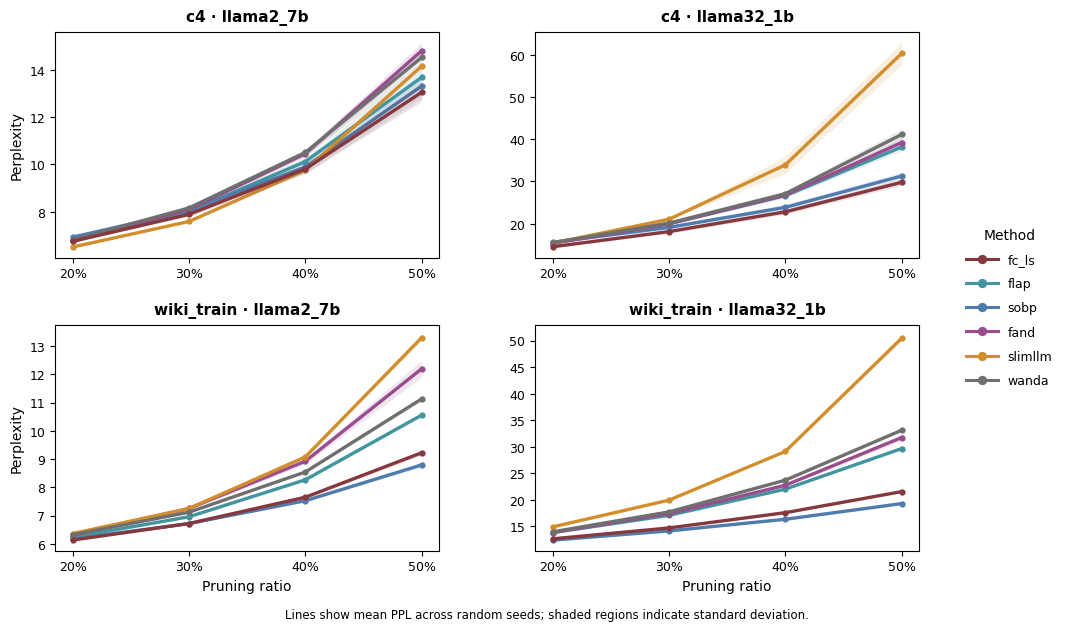

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=False)
axes = axes.flatten()

for panel_idx, (domain, model) in enumerate(panel_order):
    ax = axes[panel_idx]
    panel_df = summary_df[(summary_df['domain'] == domain) & (summary_df['model'] == model)]

    for method in methods:
        method_df = panel_df[panel_df['method'] == method].sort_values('ratio')
        if method_df.empty:
            continue

        ratios = method_df['ratio'].to_numpy(dtype=float)
        means = method_df['mean'].to_numpy(dtype=float)
        errors = method_df[error_type].to_numpy(dtype=float)
        color = colors.get(method, '#6F6F6F')

        line_zorder = 10 if method == "fc_ls" else 5
        fill_zorder = 9 if method == "fc_ls" else 4

        ax.plot(ratios, means, color=color, marker=markers.get(method, 'o'), linewidth=2.4, markersize=3.5, markeredgewidth=1.0, zorder=line_zorder)
        ax.fill_between(ratios, means - errors, means + errors, color=color, alpha=0.14, linewidth=0, zorder=fill_zorder)

    ax.set_title(f'{domain} · {model}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks(pruning_ratios)
    ax.set_xticklabels([f'{ratio}%' for ratio in pruning_ratios])
    ax.tick_params(axis='both', labelsize=9, direction='out', length=3.5, width=0.8)
    # ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)

    if panel_idx % 2 == 0:
        ax.set_ylabel('Perplexity', fontsize=10)
    if panel_idx >= 2:
        ax.set_xlabel('Pruning ratio', fontsize=10)

legend_handles = [
    Line2D([0], [0], color=colors.get(method, '#6F6F6F'), marker=markers.get(method, 'o'), linewidth=2.2, markersize=5.5, markeredgewidth=1.2, label=method)
    for method in methods
]

fig.legend(handles=legend_handles, title='Method', loc='center left', bbox_to_anchor=(0.84, 0.5), frameon=False, fontsize=9, title_fontsize=10, handlelength=2.5, labelspacing=0.9)

error_label = 'standard deviation' if error_type == 'std' else 'standard error'
fig.text(0.5, 0.01, f'Lines show mean PPL across random seeds; shaded regions indicate {error_label}.', ha='center', va='bottom', fontsize=8.5)
fig.subplots_adjust(left=0.09, right=0.81, bottom=0.12, top=0.93, wspace=0.25, hspace=0.30)

plt.savefig(output_dir / 'pruning_results.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'pruning_results.png', dpi=300, bbox_inches='tight')
plt.show()